In [79]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
import geopandas as gpd
from mpl_toolkits.basemap import Basemap
from scipy.interpolate import griddata
from scipy.spatial import cKDTree

from watobs import CMEMSSatObsRepository

import copernicusmarine

# First time users
First time users of the Copernicus Marine API will need to create an account at https://marine.copernicus.eu/ and generate an API key.

Below you call the login function to authenticate your credentials. You only have to do this the first time you use the API on a PC.



In [80]:
if not CMEMSSatObsRepository.validate_login():
    copernicusmarine.login()

# Introduction to CMEMS Scatterometry Data
## Basic workflow process

#### Step 1
Define which dataset you are interested in by creating a repository object. You can either specify a `product_id` to download multiple satellites at once, or a `dataset_id` to download a single satellite.
> ```python
> repo = CMEMSSatObsRepository(product_id="...") # or dataset_id="..."
> ```

#### Step 2
Download the data for your area and time period of interest. The data is returned as a `watobs.AltimetryData` object.
> ```python
> data = repo.get_observation_stats(
>     start_date="YYYY-MM-DD", 
>     end_date="YYYY-MM-DD", 
>     area = f"bbox={lon_min},{lat_min},{lon_max},{lat_max}",
> )
> ```

#### Step 3
Plot, export, etc. It's your data now!

## Available datasets
### Specify dataset of product to be downloaded from CMEMS Online Catalogue
- Click through the catalogue here: https://data.marine.copernicus.eu/products?pk_vid=bfd50509683fc0421764148768aca348 

Downloading **multiple satellites** at once: Options are currently: **`product_id`**`=...`
- Waves
  - "WAVE_GLO_PHY_SWH_L3_MY_014_005" 
  - "WAVE_GLO_PHY_SWH_L3_NRT_014_001"
- Wind
  - "WIND_GLO_PHY_L3_MY_012_005" 
  - "WIND_GLO_PHY_L3_NRT_012_002"
- Spectral wave parameters (CFOSAT). For now, we only provide Hm0, Tp and PWD
  - "WAVE_GLO_PHY_SPC_L3_NRT_014_009"

Downloading **a single satellite** e.g. **`dataset_id`**`='cmems_obs-wind_glo_phy_nrt_l3-hy2b-hscat-asc-0.25deg_P1D-i'`
- Too many to list here!

Ideally there would be a better way to specify this in the future

# Example - Typhoon Lingling in 2019 in the Philippine Sea

## Scatterometer Wind
Wide swath data

In [81]:
repo = CMEMSSatObsRepository(dataset_id="cmems_obs-wind_glo_phy_my_l3-metopa-ascat-des-0.125deg_P1D-i")

Loading CMEMS dataset id: cmems_obs-wind_glo_phy_my_l3-metopa-ascat-des-0.125deg_P1D-i
	Done!


### Datasets from dataset `cmems_obs-wind_glo_phy_my_l3-metopa-ascat-des-0.125deg_P1D-i`
- Found when looking through the cmems Marine Data Store

In [82]:
datasets = repo.datasets
datasets.head()

,source,source_type,obs_type,coverage,ocean_category,param,multiyear_or_nearrealtime,short_name,processing_level,asc_desc,spatial_resolution,temporal_resolution,temporal_type,min_date,max_date
dataset_id,,,,,,,,,,,,,,,
cmems_obs-wind_glo_phy_my_l3-metopa-ascat-des-0.125deg_P1D-i,cmems,obs,wind,glo,phy,None,my,metopa,l3,des,0.125deg,P1D,i,2007-01-01 00:00:00+00:00,2021-11-15 00:00:00+00:00


### Subsetting in time and space

In [83]:
start_time="2019-01-01"
end_time="2019-12-31"

lon_min = 105
lat_min = -5
lon_max = 145
lat_max = 40

area = f"bbox={lon_min},{lat_min},{lon_max},{lat_max}"

In [84]:
data = repo.get_satobs_data(
    start_time=start_time,
    end_time=end_time,
    area=area,
)

-- Downloading subset of cmems_obs-wind_glo_phy_my_l3-metopa-ascat-des-0.125deg_P1D-i


INFO - 2025-12-08T08:54:00Z - Selected dataset version: "202311"
INFO - 2025-12-08T08:54:00Z - Selected dataset part: "default"
INFO - 2025-12-08T08:54:03Z - Starting download. Please wait...


  0%|          | 0/1269 [00:00<?, ?it/s]

INFO - 2025-12-08T08:56:09Z - Successfully downloaded to d:\raiw\.cmems_udsfch6l\cmems_obs-wind_glo_phy_my_l3-metopa-ascat-des-0.125deg_P1D-i_multi-vars_105.06E-144.94E_4.94S-39.94N_2019-01-01-2019-12-31.nc


-- Download successful.
Formatting data to DataFrame...
	Done!


### Slicing in time
- Looking for data close to 2019-09-04 01:22, which is when a background picture of the typhoon is found online.
- Also removing data with longitude less than 115 for plotting purposes

In [85]:
df = data.df
df_wind = df[(df.index > pd.to_datetime('2019-09-04 01:22:00')) & (df.index < pd.to_datetime('2019-09-04 01:29:00'))]
df_wind_reduced = df_wind[df_wind.longitude > 115]


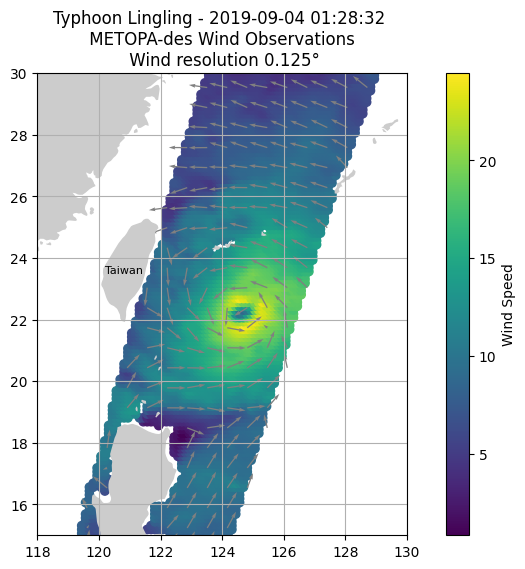

In [86]:
coastline = gpd.read_file("https://d2ad6b4ur7yvpq.cloudfront.net/naturalearth-3.3.0/ne_50m_coastline.geojson")
countries = gpd.read_file("https://d2ad6b4ur7yvpq.cloudfront.net/naturalearth-3.3.0/ne_50m_admin_0_countries.geojson")

# Create a matplotlib Axes object
fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(df_wind_reduced['longitude'], df_wind_reduced['latitude'],
                c=df_wind_reduced['WS'], cmap='viridis', label='Data Points')
plt.colorbar(sc, ax=ax, label='Wind Speed')

# Original coordinates and wind components
lon = df_wind_reduced['longitude'].values
lat = df_wind_reduced['latitude'].values

# Create structured grid (every 0.5 degrees)
lon_grid = np.arange(lon.min(), lon.max(), 0.65)
lat_grid = np.arange(lat.min(), lat.max(), 0.65)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

# Interpolate u and v onto the grid
# Be wary about the sign convention here!
wd_rad = np.deg2rad(df_wind_reduced['WD'])
u = np.sin(wd_rad)  # East-West component
v = np.cos(wd_rad)  # North-South component
u_grid = griddata((lon, lat), u, (lon_mesh, lat_mesh), method='linear')
v_grid = griddata((lon, lat), v, (lon_mesh, lat_mesh), method='linear')

## This part is to exclude data interpolation between swaths - which would be incorrect to do and show.
# Build KDTree for original observation points
tree = cKDTree(np.c_[lon, lat])

# Compute distance from each grid point to nearest observation
dist, _ = tree.query(np.c_[lon_mesh.ravel(), lat_mesh.ravel()])
dist = dist.reshape(lon_mesh.shape)

# Define a threshold (in degrees) beyond which arrows are masked
threshold = 0.5  # Adjust based on swath width
mask = dist > threshold

# Apply mask to u and v grids
u_grid[mask] = np.nan
v_grid[mask] = np.nan

# Plot quiver with masked data
q2 = ax.quiver(lon_mesh, lat_mesh, u_grid, v_grid, scale=20, width=0.0035, color='grey')

countries.plot(ax=ax, color='0.8')

xlim = (118, 130)
ylim = (15, 30)

for idx, row in countries.iterrows():
    point = row['geometry'].representative_point()
    if xlim[0] <= point.x <= xlim[1] and ylim[0] <= point.y <= ylim[1]:
        ax.text(point.x, point.y, row['admin'], fontsize=8, ha='center', va='center')

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_aspect(1.0 / np.cos(np.pi * 1 / 180))
ax.grid(True)

ax.set_title(f'Typhoon Lingling - {df_wind_reduced.index[0]} \n METOPA-des Wind Observations \n Wind resolution 0.125°')

plt.show()

In [87]:
start_time="2019-09-01"
end_time="2019-9-30"

### Wind data looks fine. Now for spectral and wave
- Downloading and slicing the spectral data the same
- !!! NOTE !!!  Downloading spectral data might require the .ipynb to be located on a local directory. Network drives can cause issues

In [88]:
repo = CMEMSSatObsRepository(dataset_id="cnes_obs-wave_glo_phy-spc_nrt_cfo-l3_PT10S")

data = repo.get_satobs_data(
    start_time=start_time,
    end_time=end_time,
    area=area,
)

df_spec = data.df
df_spec_reduced = df_spec[(df_spec.index > pd.to_datetime('2019-09-04 00:00:00')) & (df_spec.index < pd.to_datetime('2019-09-04 23:59:00'))]

Loading CMEMS dataset id: cnes_obs-wave_glo_phy-spc_nrt_cfo-l3_PT10S
	Done!
No time coordinates found in part 'default'.
No time coordinates found in part 'default'.
-- Downloading subset of cnes_obs-wave_glo_phy-spc_nrt_cfo-l3_PT10S


INFO - 2025-12-08T09:00:35Z - Selected dataset version: "202406"
INFO - 2025-12-08T09:00:35Z - Selected dataset part: "default"
Subset download failed: No service available for dataset with command subset. Falling back to full dataset download.


-- Downloading September 2019


INFO - 2025-12-08T09:00:41Z - Selected dataset version: "202406"
INFO - 2025-12-08T09:00:41Z - Selected dataset part: "default"
INFO - 2025-12-08T09:00:42Z - Listing files on remote server...
45it [00:11,  3.90it/s]


-- Download successful.
Formatting data to DataFrame...
Merging files for 2019


Empty data from cnes_obs-wave_glo_phy-spc_nrt_cfo-l3_PT10S_20190904T024123Z_20190904T025251Z_P20240516T142100Z.nc, skipping
Empty data from cnes_obs-wave_glo_phy-spc_nrt_cfo-l3_PT10S_20190905T150757Z_20190905T152217Z_P20240516T142100Z.nc, skipping
Empty data from cnes_obs-wave_glo_phy-spc_nrt_cfo-l3_PT10S_20190907T143917Z_20190907T145306Z_P20240516T142100Z.nc, skipping
Empty data from cnes_obs-wave_glo_phy-spc_nrt_cfo-l3_PT10S_20190909T141929Z_20190909T142358Z_P20240516T142100Z.nc, skipping
Empty data from cnes_obs-wave_glo_phy-spc_nrt_cfo-l3_PT10S_20190911T151522Z_20190911T152950Z_P20240516T142100Z.nc, skipping
Empty data from cnes_obs-wave_glo_phy-spc_nrt_cfo-l3_PT10S_20190914T143221Z_20190914T144604Z_P20240516T142100Z.nc, skipping
Empty data from cnes_obs-wave_glo_phy-spc_nrt_cfo-l3_PT10S_20190922T141956Z_20190922T142424Z_P20240516T142100Z.nc, skipping
Empty data from cnes_obs-wave_glo_phy-spc_nrt_cfo-l3_PT10S_20190925T150126Z_20190925T151539Z_P20240516T142100Z.nc, skipping
Empty da

	Done!
No time coordinates found in part 'default'.


### Wind data looks fine.
- Downloading and slicing the wave data the same

In [89]:
repo = CMEMSSatObsRepository(dataset_id="cmems_obs-wave_glo_phy-swh_my_cfo-l3_PT1S")

data = repo.get_satobs_data(
    start_time=start_time,
    end_time=end_time,
    area=area,
)

df_wave = data.df
df_wave_reduced = df_wave[(df_wave.index > pd.to_datetime('2019-09-04 00:00:00')) & (df_wave.index < pd.to_datetime('2019-09-04 23:59:00'))]

Loading CMEMS dataset id: cmems_obs-wave_glo_phy-swh_my_cfo-l3_PT1S
	Done!
-- Downloading subset of cmems_obs-wave_glo_phy-swh_my_cfo-l3_PT1S


INFO - 2025-12-08T09:09:33Z - Selected dataset version: "202112"
INFO - 2025-12-08T09:09:33Z - Selected dataset part: "default"


-- Download successful.
Formatting data to DataFrame...
<_io.BufferedReader name='d:\\raiw\\.cmems_coh6k1kw\\cmems_obs-wave_glo_phy-swh_my_cfo-l3_PT1S_VAVH-VAVH_UNFILTERED_105.00E-145.00E_5.00S-40.00N_2019-09-01-2019-09-30.csv'>
	Done!


c:\Users\raiw\Desktop\cloned_repos\watobs\.venv\Lib\site-packages\geopandas\plotting.py:480: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  ax.figure.canvas.draw_idle()


Text(0.5, 1.0, 'Typhoon Lingling - 2019-09-04 01:28:32 \n Wind resolution 0.125° from METOPA sat. \n Wave resolution 7 x 7 km from CFOSAT \n Spectral resolution 70 x 90 km from CFOSAT')

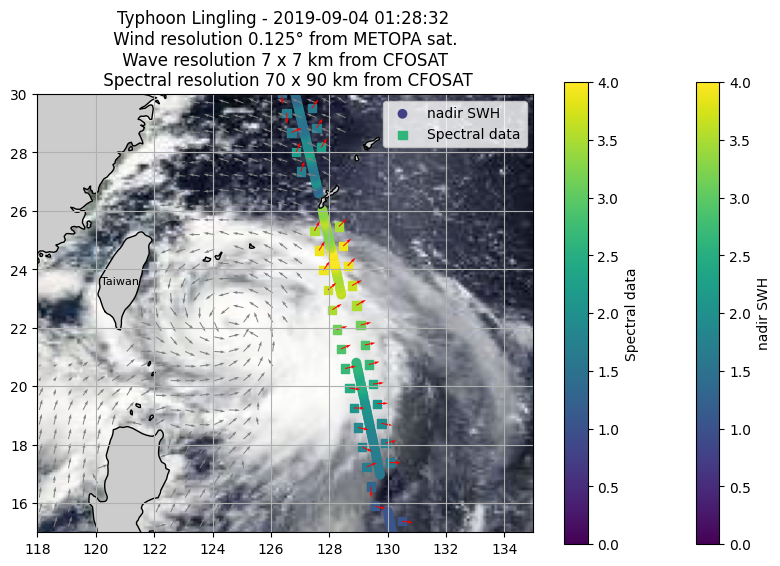

In [90]:
wd_rad = np.deg2rad(df_wind['WD'][0::5])
wave_d_rad = np.deg2rad(df_spec_reduced['PWD'])

# Calculate vector components
# Here wind blow towards, therefore no negative sign
u = np.sin(wd_rad)  # East-West component
v = np.cos(wd_rad)  # North-South component
u_w = np.sin(wave_d_rad)  # East-West component
v_w = np.cos(wave_d_rad)  # North-South component

# Load background image
img = mpimg.imread('snapshot-2019-09-04.jpg')
# https://wvs.earthdata.nasa.gov/api/v1/snapshot?REQUEST=GetSnapshot&TIME=2019-09-04T00:00:00Z&BBOX=13.5308,117.0052,30.8115,132.4344&CRS=EPSG:4326&LAYERS=MODIS_Terra_CorrectedReflectance_TrueColor,Coastlines_15m&WRAP=day,x&FORMAT=image/jpeg&WIDTH=1756&HEIGHT=1966&colormaps=,&ts=1761728036609

# Create a matplotlib Axes object
fig, ax = plt.subplots(figsize=(10, 6))

ax.imshow(img, extent=[117.0052, 135, 13.5308, 30.8115], origin='upper')

sc = ax.scatter(df_wave_reduced['longitude'], df_wave_reduced['latitude'],
                c=df_wave_reduced['SWH'], cmap='viridis', vmax = 4, vmin = 0, label='nadir SWH')

sc_spec = ax.scatter(df_spec_reduced['longitude'], df_spec_reduced['latitude'],
                c=df_spec_reduced['SWH'], marker='s', cmap='viridis', vmax = 4, vmin = 0, label='Spectral data')
plt.colorbar(sc, ax=ax, label='nadir SWH')
plt.colorbar(sc_spec, ax=ax, label='Spectral data')

# Original coordinates and wind components
lon = df_wind['longitude'].values
lat = df_wind['latitude'].values
wd_rad = np.deg2rad(df_wind['WD'].values)
u = np.sin(wd_rad)
v = np.cos(wd_rad)

# Create structured grid (every 0.5 degrees)
lon_grid = np.arange(lon.min(), lon.max(), 0.5)
lat_grid = np.arange(lat.min(), lat.max(), 0.5)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

# Interpolate u and v onto the grid
u_grid = griddata((lon, lat), u, (lon_mesh, lat_mesh), method='linear')
v_grid = griddata((lon, lat), v, (lon_mesh, lat_mesh), method='linear')
# Plot quiver on structured grid
q2 = ax.quiver(lon_mesh, lat_mesh, u_grid, v_grid, scale=45, width=0.002, color='grey')

#q = ax.quiver(df_wind_reduced['longitude'][0::5], df_wind_reduced['latitude'][0::5],
#              u, v, scale=45, width=0.002, color='grey')
q_w = ax.quiver(df_spec_reduced['longitude'], df_spec_reduced['latitude'],
              u_w, v_w, scale=45, width=0.002, color='red')

ax.legend()

xlim = (118, 135)
ylim = (15, 30)

# Plot countries
countries.plot(ax=ax, color='0.8', edgecolor='black')

# Add labels only for countries within the visible bounds
for idx, row in countries.iterrows():
    point = row['geometry'].representative_point()
    if xlim[0] <= point.x <= xlim[1] and ylim[0] <= point.y <= ylim[1]:
        ax.text(point.x, point.y, row['admin'], fontsize=8, ha='center', va='center')

# Lock axis limits
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.grid(True)
# Resolution documentation:
# Wind: https://data.marine.copernicus.eu/product/WIND_GLO_PHY_L3_NRT_012_002/description
# Wave: https://data.marine.copernicus.eu/product/WAVE_GLO_PHY_SWH_L3_NRT_014_001/description
# Spectral: https://data.marine.copernicus.eu/product/WAVE_GLO_PHY_SPC_L3_NRT_014_009/description
ax.set_title(f'Typhoon Lingling - {df_reduced.index[0]} \n Wind resolution 0.125° from METOPA sat. \n Wave resolution 7 x 7 km from CFOSAT \n Spectral resolution 70 x 90 km from CFOSAT')